# 📊 Tradebook Analysis — Generalised & Robust
> Works with **any** CSV tradebook: equities, crypto, futures, forex.  
> Supports Google Colab, local Jupyter, and JupyterLab.  
>
> **To get started:** edit the `CONFIG` dict in the next cell, then run all.


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  ⚙️  CONFIGURATION — Edit this block before running                      ║
# ╚══════════════════════════════════════════════════════════════════════════╝

CONFIG = {

    # ── Data Source ──────────────────────────────────────────────────────────
    # Local path (used when NOT running in Google Colab)
    "local_file_path": "tradebook.csv",
    # Path relative to Google Drive root (Colab only)
    "gdrive_file_path": "/content/drive/MyDrive/1tradebook.csv",

    # ── Capital & Leverage ────────────────────────────────────────────────────
    "starting_capital": 100_000,      # Base capital (₹ / $) for % return maths
    "leverage":         1,           # Max leverage used by the strategy
    "margin_call_threshold": 0.25,    # Broker margin-call trigger (fraction of margin)

    # ── Risk-Free Rate ─────────────────────────────────────────────────────────
    "risk_free_rate_annual": 0.0,    # e.g. 0.06 = 6 % p.a.

    # ── Annualisation ──────────────────────────────────────────────────────────
    "trading_days_per_year": 365,     # 252 for equities; 365 for 24/7 crypto

    # ── Rolling Sharpe ─────────────────────────────────────────────────────────
    "rolling_sharpe_window": 3,       # Rolling window in months

    # ── Benchmark ─────────────────────────────────────────────────────────────
    # Set to a ticker present in the data, or None to skip.
    "benchmark_ticker": None,         # e.g. "BTCUSDT" or "NIFTY"

    # ── Time Filter ────────────────────────────────────────────────────────────
    # Trades entered at exactly this time are removed (opening-auction artefacts).
    # Set to None to keep all trades.
    "filter_open_auction_time": None, # e.g. "09:15"

    # ── Monte Carlo ────────────────────────────────────────────────────────────
    "mc_simulations":   10_000,
    "mc_paths_to_plot": 500,

    # ── Weighted Portfolio ─────────────────────────────────────────────────────
    # Supply {ticker: weight} summing to ~1.0, or None for auto equal-weighting.
    "ticker_weights": None,
    # Example:
    # "ticker_weights": {"BTCUSDT": 0.40, "ETHUSDT": 0.30, "SOLUSDT": 0.30},

    # ── Column-name overrides ──────────────────────────────────────────────────
    # Set to None for auto-detection; override only if auto-detect fails.
    "col_entry_time":  None,
    "col_exit_time":   None,
    "col_pnl":         None,
    "col_ticker":      None,
    "col_direction":   None,
    "col_exit_reason": None,
    "col_entry_price": None,
    "col_exit_price":  None,
}


## 🚀 Section 1 — Setup

In [10]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  📦 Imports                                                               ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import calendar

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize":  (14, 6),
    "axes.titlesize":  14,
    "axes.labelsize":  12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
print("✅ Libraries imported successfully.")


✅ Libraries imported successfully.


In [11]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  📂 Data Loading — auto-detects Colab vs local                            ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def _is_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def load_data(config: dict) -> pd.DataFrame:
    if _is_colab():
        from google.colab import drive
        drive_root = "/content/drive"
        if not os.path.ismount(drive_root):
            drive.mount(drive_root)
        path = os.path.join(drive_root, "MyDrive", config["gdrive_file_path"])
    else:
        path = config["local_file_path"]

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"❌  File not found: '{path}'\n"
            "Please update CONFIG['local_file_path'] "
            "(or 'gdrive_file_path' when using Colab)."
        )

    df = pd.read_csv(path)
    print(f"✅  Loaded {len(df):,} rows × {len(df.columns)} columns  from: {path}")
    print(f"    Columns : {list(df.columns)}")
    return df


df_raw = load_data(CONFIG)
df_raw.head(3)


✅  Loaded 341 rows × 9 columns  from: /content/drive/MyDrive/1tradebook.csv
    Columns : ['Ticker', 'Entry Time', 'Entry Price', 'Exit Time', 'Exit Price', 'PNL', 'Exit Reason', 'Cumulative PNL', 'Position']


,Ticker,Entry Time,Entry Price,Exit Time,Exit Price,PNL,Exit Reason,Cumulative PNL,Position
0,ICICIBANK,2022-01-04 11:12:00,773.35,2022-01-04 15:25:00,773.40,-93.534622,TP/SL/Close Time,-93.534622,Long
1,ICICIBANK,2022-01-05 11:14:00,785.05,2022-01-05 15:25:00,787.40,199.343991,TP/SL/Close Time,105.809369,Long
2,ICICIBANK,2022-01-06 09:29:00,776.05,2022-01-06 14:31:00,791.65,1910.179756,TP/SL/Close Time,2015.989125,Long


In [12]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  🔍 Column Detection & Preprocessing                                      ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# ── Known aliases for each logical column ────────────────────────────────────
_ALIASES = {
    "col_entry_time":  ["Entry Time","Entry Date","EntryTime","entry_time",
                        "entry_date","Open Time","OpenTime","open_time"],
    "col_exit_time":   ["Exit Time","Exit Date","ExitTime","exit_time",
                        "exit_date","Close Time","CloseTime","close_time"],
    "col_pnl":         ["PnL","pnl","P&L","Profit","Net PnL","Net P&L", "PNL",
                        "realized_pnl","profit","Realised PnL","Realized PnL"],
    "col_ticker":      ["Ticker","ticker","Symbol","symbol","Instrument",
                        "instrument","Asset","asset","Pair","pair"],
    "col_direction":   ["Direction","direction","Side","side","Type","type",
                        "Long_Short","long_short","trade_type"],
    "col_exit_reason": ["Exit Reason","exit_reason","ExitReason",
                        "Close Reason","close_reason","Signal","signal"],
    "col_entry_price": ["Entry Price","entry_price","EntryPrice",
                        "Open Price","open_price","Buy Price","buy_price"],
    "col_exit_price":  ["Exit Price","exit_price","ExitPrice",
                        "Close Price","close_price","Sell Price","sell_price"],
}

_STD_NAMES = {
    "col_entry_time":  "Entry Time",
    "col_exit_time":   "Exit Time",
    "col_pnl":         "PnL",
    "col_ticker":      "Ticker",
    "col_direction":   "Direction",
    "col_exit_reason": "Exit Reason",
    "col_entry_price": "Entry Price",
    "col_exit_price":  "Exit Price",
}


def _resolve(df: pd.DataFrame, key: str, config: dict):
    override = config.get(key)
    if override:
        if override in df.columns:
            return override
        raise ValueError(f"CONFIG['{key}'] = '{override}' not found in DataFrame.")
    for alias in _ALIASES.get(key, []):
        if alias in df.columns:
            return alias
    return None


def resolve_columns(df: pd.DataFrame, config: dict) -> dict:
    cols = {k: _resolve(df, k, config) for k in _ALIASES}
    for req in ("col_entry_time", "col_exit_time", "col_pnl"):
        if cols[req] is None:
            raise ValueError(
                f"❌  Cannot detect required column '{req}'.\n"
                f"Set CONFIG['{req}'] explicitly.\nFound: {list(df.columns)}"
            )
    return cols


def preprocess(raw: pd.DataFrame, config: dict) -> pd.DataFrame:
    """Normalise columns, parse datetimes, derive helper fields."""
    cols = resolve_columns(raw, config)
    df = raw.copy()

    # Rename to standard names
    rename = {cols[k]: std for k, std in _STD_NAMES.items()
              if cols[k] and cols[k] != std}
    df.rename(columns=rename, inplace=True)

    # Parse datetimes (UTC-aware, tolerant of mixed formats)
    for col in ("Entry Time", "Exit Time"):
        df[col] = pd.to_datetime(df[col], utc=True, format="mixed", errors="coerce")
    df.dropna(subset=["Entry Time", "Exit Time", "PnL"], inplace=True)
    df.sort_values("Entry Time", inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Normalise Direction to Title-case
    if "Direction" in df.columns:
        df["Direction"] = df["Direction"].astype(str).str.strip().str.title()

    # Optional: filter opening-auction trades
    ft = config.get("filter_open_auction_time")
    if ft:
        t = pd.to_datetime(ft).time()
        mask = df["Entry Time"].dt.time == t
        n = mask.sum()
        df = df[~mask].reset_index(drop=True)
        if n:
            print(f"ℹ️   Removed {n} trades at {ft} (open-auction filter).")

    # Derived columns
    df["Weekday"]       = df["Exit Time"].dt.day_name()
    df["Hour"]          = df["Entry Time"].dt.hour
    df["Year"]          = df["Entry Time"].dt.year
    df["Month"]         = df["Entry Time"].dt.month
    df["Trade Date"]    = df["Entry Time"].dt.date
    df["YearMonth"]     = df["Entry Time"].dt.to_period("M")
    df["Holding Time (h)"] = (
        (df["Exit Time"] - df["Entry Time"]).dt.total_seconds() / 3600
    )
    df["Win"]  = df["PnL"] > 0
    df["Loss"] = df["PnL"] < 0

    return df


COLS = resolve_columns(df_raw, CONFIG)
df   = preprocess(df_raw, CONFIG)

optional = {k: v for k, v in COLS.items()
            if k not in ("col_entry_time","col_exit_time","col_pnl")}
print(f"\n📋  Preprocessed shape  : {df.shape}")
print(f"    Date range          : {df['Entry Time'].min().date()} → {df['Exit Time'].max().date()}")
print(f"    PnL  range          : {df['PnL'].min():>12,.2f}  →  {df['PnL'].max():,.2f}")
print(f"    Optional cols found : { {k:v for k,v in optional.items() if v} }")
df.head()



📋  Preprocessed shape  : (341, 18)
    Date range          : 2022-01-04 → 2024-11-07
    PnL  range          :    -2,297.22  →  2,178.21
    Optional cols found : {'col_ticker': 'Ticker', 'col_exit_reason': 'Exit Reason', 'col_entry_price': 'Entry Price', 'col_exit_price': 'Exit Price'}


,Ticker,Entry Time,Entry Price,Exit Time,Exit Price,PnL,Exit Reason,Cumulative PNL,Position,Weekday,Hour,Year,Month,Trade Date,YearMonth,Holding Time (h),Win,Loss
0,ICICIBANK,2022-01-04 11:12:00+00:00,773.35,2022-01-04 15:25:00+00:00,773.40,-93.534622,TP/SL/Close Time,-93.534622,Long,Tuesday,11,2022,1,2022-01-04,2022-01,4.216667,False,True
1,ICICIBANK,2022-01-05 11:14:00+00:00,785.05,2022-01-05 15:25:00+00:00,787.40,199.343991,TP/SL/Close Time,105.809369,Long,Wednesday,11,2022,1,2022-01-05,2022-01,4.183333,True,False
2,ICICIBANK,2022-01-06 09:29:00+00:00,776.05,2022-01-06 14:31:00+00:00,791.65,1910.179756,TP/SL/Close Time,2015.989125,Long,Thursday,9,2022,1,2022-01-06,2022-01,5.033333,True,False
3,ICICIBANK,2022-01-10 10:45:00+00:00,802.20,2022-01-10 15:25:00+00:00,812.25,1152.804787,TP/SL/Close Time,3168.793912,Long,Monday,10,2022,1,2022-01-10,2022-01,4.666667,True,False
4,ICICIBANK,2022-01-11 09:40:00+00:00,803.75,2022-01-11 15:25:00+00:00,810.85,783.359253,TP/SL/Close Time,3952.153166,Long,Tuesday,9,2022,1,2022-01-11,2022-01,5.750000,True,False


## 📊 Section 2 — PnL Analysis

In [13]:
# ── 1. PnL Distribution ──────────────────────────────────────────────────────
def plot_pnl_distribution(df: pd.DataFrame):
    fig = px.histogram(
        df, x="PnL", nbins=300, marginal="rug",
        title="Distribution of PnL",
        opacity=0.75,
        color_discrete_sequence=["forestgreen"],
        template="plotly_white",
    )
    fig.add_vline(x=0, line_dash="dash", line_color="red",
                  annotation_text="Break-even")
    fig.update_layout(xaxis_title="PnL", yaxis_title="Frequency", bargap=0.05)
    fig.show()

plot_pnl_distribution(df)


In [14]:
# ── 2. PnL by Exit Reason  (skipped if column absent) ────────────────────────
def plot_pnl_by_exit_reason(df: pd.DataFrame):
    if "Exit Reason" not in df.columns:
        print("⚠️   Skipping — 'Exit Reason' column not found.")
        return

    fig = px.histogram(
        df, x="PnL", facet_col="Exit Reason",
        color="Exit Reason", nbins=100, opacity=0.75,
        title="PnL Distribution by Exit Reason",
        color_discrete_sequence=px.colors.qualitative.Set2,
        template="plotly_white",
    )
    fig.update_layout(showlegend=False, height=420)
    fig.update_xaxes(matches=None, showticklabels=True)
    fig.show()

    stats = (
        df.groupby("Exit Reason")["PnL"]
        .agg(["sum","mean","count"])
        .rename(columns={"sum":"Total PnL","mean":"Avg PnL","count":"Trades"})
        .sort_values("Total PnL", ascending=False)
    )
    print("\n📊 Exit Reason Summary:")
    print(stats.to_string())

    fig2 = px.bar(
        stats.reset_index(), x="Exit Reason", y="Total PnL",
        color="Total PnL",
        color_continuous_scale=["red","white","green"],
        color_continuous_midpoint=0,
        text=stats["Total PnL"].round(0).astype(int).values,
        title="Total PnL by Exit Reason",
        template="plotly_white",
    )
    fig2.update_traces(textposition="outside")
    fig2.show()

plot_pnl_by_exit_reason(df)



📊 Exit Reason Summary:
                     Total PnL    Avg PnL  Trades
Exit Reason                                      
TP/SL/Close Time  28394.178886  83.267387     341


In [15]:
# ── 3. Win/Loss Count & Total PnL by Ticker ──────────────────────────────────
def plot_trade_summary(df: pd.DataFrame):
    if "Ticker" not in df.columns:
        print("⚠️   Skipping — 'Ticker' column not found.")
        return

    summary = (
        df.groupby("Ticker")
        .agg(
            Total_Trades   =("PnL","count"),
            Winning_Trades =("Win","sum"),
            Losing_Trades  =("Loss","sum"),
            Total_PnL      =("PnL","sum"),
            Win_Rate       =("Win","mean"),
        )
        .reset_index()
        .sort_values("Total_PnL", ascending=False)
    )
    summary["Win_Rate"] = (summary["Win_Rate"] * 100).round(1)

    melted = summary.melt(
        id_vars="Ticker",
        value_vars=["Winning_Trades","Losing_Trades"],
        var_name="Trade Type", value_name="Count",
    )
    fig = px.bar(
        melted, x="Ticker", y="Count", color="Trade Type",
        barmode="group", text_auto=True,
        title="Win / Loss Count by Ticker",
        color_discrete_map={"Winning_Trades":"green","Losing_Trades":"red"},
        template="plotly_white",
    )
    fig.update_layout(xaxis_tickangle=-45, legend_title_text="Outcome")
    fig.show()

    fig2 = px.bar(
        summary, x="Ticker", y="Total_PnL",
        color="Total_PnL",
        color_continuous_scale=["red","white","green"],
        color_continuous_midpoint=0,
        text=summary["Total_PnL"].round(0).astype(int),
        title="Total PnL by Ticker",
        template="plotly_white",
    )
    fig2.update_traces(textposition="outside")
    fig2.update_layout(xaxis_tickangle=-45, showlegend=False)
    fig2.show()

plot_trade_summary(df)


In [16]:
# ── 4. PnL by Weekday ────────────────────────────────────────────────────────
def plot_pnl_by_weekday(df: pd.DataFrame):
    order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    wd = (
        df.groupby("Weekday")["PnL"]
        .agg(["sum","mean","count"])
        .rename(columns={"sum":"Total PnL","mean":"Avg PnL","count":"Trades"})
        .reset_index()
    )
    wd["Weekday"] = pd.Categorical(wd["Weekday"], categories=order, ordered=True)
    wd = wd.sort_values("Weekday")
    wd["Color"] = wd["Total PnL"].apply(lambda x: "Positive" if x >= 0 else "Negative")

    fig = px.bar(
        wd, x="Weekday", y="Total PnL",
        color="Color",
        text=wd["Total PnL"].round(0).astype(int),
        color_discrete_map={"Positive":"green","Negative":"red"},
        title="Total PnL by Weekday",
        template="plotly_white",
        hover_data={"Trades":True,"Avg PnL":":.2f"},
    )
    fig.update_traces(textposition="outside")
    fig.update_layout(legend_title_text="PnL Type")
    fig.show()

plot_pnl_by_weekday(df)


In [17]:
# ── 5. Win Rate by Direction per Ticker  (skipped if columns absent) ─────────
def plot_win_rate_by_direction(df: pd.DataFrame):
    for col in ("Direction","Ticker"):
        if col not in df.columns:
            print(f"⚠️   Skipping — '{col}' column not found.")
            return

    stats = (
        df.groupby(["Ticker","Direction"])
        .agg(Total=("PnL","count"), Wins=("Win","sum"))
        .reset_index()
    )
    stats["Win Rate (%)"] = (stats["Wins"] / stats["Total"] * 100).round(2)

    print("\n📊 Win Rate by Direction per Ticker:")
    pivot_str = (
        stats.pivot(index="Ticker", columns="Direction", values="Win Rate (%)")
        .fillna("—")
    )
    print(pivot_str.to_string())

    fig = px.bar(
        stats, x="Ticker", y="Win Rate (%)", color="Direction",
        barmode="group", text="Win Rate (%)",
        title="Win Rate by Direction per Ticker",
        color_discrete_map={"Long":"green","Short":"red"},
        template="plotly_white",
    )
    fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
    fig.update_layout(xaxis_tickangle=-45, yaxis_range=[0, 115])
    fig.show()

    grouped = df.groupby(["Ticker","Direction"])["PnL"].sum().unstack(fill_value=0)
    ax = grouped.plot(kind="bar", figsize=(13, 5))
    ax.set_title("Cumulative PnL by Ticker and Direction")
    ax.set_xlabel("Ticker"); ax.set_ylabel("Cumulative PnL")
    ax.legend(title="Direction")
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

plot_win_rate_by_direction(df)


⚠️   Skipping — 'Direction' column not found.


In [18]:
# ── 6. Hourly Analysis ───────────────────────────────────────────────────────
def plot_hourly_analysis(df: pd.DataFrame):
    d = df.copy()
    d["Trade Type"] = d["PnL"].apply(lambda x: "Win" if x > 0 else "Loss")
    pnl_per_hour    = d.groupby("Hour")["PnL"].sum().reset_index()

    fig = make_subplots(
        rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.12,
        subplot_titles=("Win & Loss Count per Hour","Total PnL per Hour"),
    )
    for ttype, color in [("Win","green"),("Loss","red")]:
        sub = d[d["Trade Type"]==ttype].groupby("Hour").size().reset_index(name="Count")
        fig.add_trace(
            go.Bar(x=sub["Hour"], y=sub["Count"], name=ttype, marker_color=color),
            row=1, col=1,
        )
    bar_colors = ["green" if v >= 0 else "red" for v in pnl_per_hour["PnL"]]
    fig.add_trace(
        go.Bar(x=pnl_per_hour["Hour"], y=pnl_per_hour["PnL"],
               name="Total PnL", marker_color=bar_colors),
        row=2, col=1,
    )
    fig.update_layout(
        title_text="Trade Analysis by Hour of Day",
        height=700, barmode="group", template="plotly_white",
    )
    fig.update_xaxes(title_text="Hour of Day (UTC)", row=2, col=1)
    fig.update_yaxes(title_text="Trades",    row=1, col=1)
    fig.update_yaxes(title_text="Total PnL", row=2, col=1)
    fig.show()

plot_hourly_analysis(df)


## 📈 Section 3 — Portfolio Performance

In [19]:
# ── 7. Portfolio Cumulative PnL & Drawdown ───────────────────────────────────
def plot_portfolio_performance(df: pd.DataFrame, config: dict):
    capital = config["starting_capital"]
    d = df.sort_values("Entry Time").reset_index(drop=True).copy()
    d["Cumulative PnL"] = d["PnL"].cumsum()
    d["Peak"]     = d["Cumulative PnL"].cummax()
    d["Drawdown"] = ((d["Cumulative PnL"] - d["Peak"]) / capital) * 100

    fig = make_subplots(
        rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.12,
        subplot_titles=(
            "Portfolio Cumulative PnL",
            f"Drawdown (% of Starting Capital = {capital:,})"
        ),
    )
    fig.add_trace(go.Scatter(
        x=d["Entry Time"], y=d["Cumulative PnL"],
        mode="lines", name="Cumulative PnL",
        line=dict(color="purple", width=1.5),
        hovertemplate="Time: %{x}<br>Cum PnL: %{y:,.2f}",
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=d["Entry Time"], y=d["Drawdown"],
        mode="lines", name="Drawdown (%)",
        fill="tozeroy", fillcolor="rgba(255,0,0,0.12)",
        line=dict(color="red", width=1.5),
        hovertemplate="Time: %{x}<br>Drawdown: %{y:.2f}%",
    ), row=2, col=1)

    fig.update_layout(height=700, template="plotly_white",
                      title_text="Portfolio Performance Overview")
    fig.update_yaxes(title_text="PnL",          row=1, col=1)
    fig.update_yaxes(title_text="Drawdown (%)",  row=2, col=1)
    fig.update_xaxes(title_text="Time",          row=2, col=1)
    fig.show()

    max_dd_pct = d["Drawdown"].min()
    idx_max    = d["Drawdown"].idxmin()
    print(f"📉 Max Drawdown : {max_dd_pct:.2f}%  "
          f"(occurred at {d.loc[idx_max,'Entry Time'].date()})")

plot_portfolio_performance(df, CONFIG)


📉 Max Drawdown : -14.61%  (occurred at 2023-01-30)


In [20]:
# ── 8. Monthly & Yearly Returns Heatmap ──────────────────────────────────────
def plot_monthly_yearly_returns(df: pd.DataFrame, config: dict):
    capital = config["starting_capital"]
    d = df.copy()
    d["Year"]  = d["Entry Time"].dt.year
    d["Month"] = d["Entry Time"].dt.month

    monthly = d.groupby(["Year","Month"])["PnL"].sum().reset_index()
    monthly["Return %"] = (monthly["PnL"] / capital) * 100
    yearly  = d.groupby("Year")["PnL"].sum().reset_index()
    yearly["Return %"]  = (yearly["PnL"]  / capital) * 100

    pivot = monthly.pivot(index="Year", columns="Month", values="Return %")
    pivot = pivot.reindex(columns=range(1, 13), fill_value=np.nan)
    pivot.columns = [calendar.month_abbr[m] for m in pivot.columns]

    text_vals = np.where(
        np.isnan(pivot.values), "",
        np.round(pivot.values, 2).astype(str)
    )
    hm = go.Figure(data=go.Heatmap(
        z=pivot.values,
        x=pivot.columns.tolist(),
        y=pivot.index.astype(str).tolist(),
        colorscale="RdBu", reversescale=True,
        colorbar_title="Return %",
        text=text_vals, texttemplate="%{text}%",
        hovertemplate="Year: %{y}<br>Month: %{x}<br>Return: %{z:.2f}%",
        zmid=0,
    ))
    hm.update_layout(
        title=f"Monthly Returns Heatmap (% of Capital = {capital:,})",
        xaxis_title="Month", yaxis_title="Year",
        template="plotly_white",
        width=1100, height=max(400, 100 * len(pivot)),
    )
    hm.show()

    colors = ["green" if r >= 0 else "red" for r in yearly["Return %"]]
    bar = go.Figure(go.Bar(
        x=yearly["Year"].astype(str), y=yearly["Return %"],
        marker_color=colors,
        text=(yearly["Return %"].round(2).astype(str) + "%"),
        textposition="outside",
    ))
    bar.update_layout(
        title="Yearly Returns (%)",
        xaxis_title="Year", yaxis_title="Return (%)",
        template="plotly_white", width=900, height=450,
    )
    bar.show()

plot_monthly_yearly_returns(df, CONFIG)


## 📐 Section 4 — Risk & Performance Metrics

In [21]:
# ── 9. Comprehensive Performance Metrics ─────────────────────────────────────
def compute_metrics(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    capital    = config["starting_capital"]
    ann_factor = config["trading_days_per_year"]
    rf_daily   = (1 + config["risk_free_rate_annual"]) ** (1 / ann_factor) - 1

    d = df.sort_values("Entry Time").reset_index(drop=True).copy()

    # Trade-level
    total  = len(d)
    wins   = d[d["PnL"] > 0]["PnL"]
    losses = d[d["PnL"] < 0]["PnL"]
    wr     = len(wins) / total
    avg_w  = wins.mean()   if len(wins)   else float("nan")
    avg_l  = losses.mean() if len(losses) else float("nan")
    avg_p  = d["PnL"].mean()
    tot_p  = d["PnL"].sum()
    pf = (wins.sum() / abs(losses.sum())
          if (len(losses) and losses.sum() != 0) else float("inf"))
    exp = wr * avg_w + (1 - wr) * (avg_l if not np.isnan(avg_l) else 0)

    # Daily
    d["Trade Date"] = d["Entry Time"].dt.date
    daily   = d.groupby("Trade Date")["PnL"].sum()
    mu_d    = daily.mean()
    sd_d    = daily.std()
    sharpe  = ((mu_d - rf_daily) / sd_d * np.sqrt(ann_factor)
               if sd_d and sd_d != 0 else float("nan"))
    down_sd = daily[daily < rf_daily].std()
    sortino = ((mu_d - rf_daily) / down_sd * np.sqrt(ann_factor)
               if (not np.isnan(down_sd) and down_sd != 0) else float("nan"))

    # Drawdown
    d["Cum PnL"] = d["PnL"].cumsum()
    peak  = d["Cum PnL"].cummax()
    dd    = peak - d["Cum PnL"]
    max_dd = dd.max()
    calmar = (mu_d * ann_factor / max_dd) if max_dd != 0 else float("nan")

    # Drawdown duration (hours)
    in_dd = False; dd_start = None; durations = []
    for i, (c, p) in enumerate(zip(d["Cum PnL"], peak)):
        if c < p:
            if not in_dd: in_dd = True; dd_start = i
        else:
            if in_dd:
                dur = (d.iloc[i]["Entry Time"] - d.iloc[dd_start]["Entry Time"]).total_seconds() / 3600
                durations.append(dur); in_dd = False
    if in_dd:
        dur = (d.iloc[-1]["Exit Time"] - d.iloc[dd_start]["Entry Time"]).total_seconds() / 3600
        durations.append(dur)
    max_dd_dur = max(durations) if durations else 0
    avg_dd_dur = np.mean(durations) if durations else 0

    # Time-in-market (merge overlapping intervals)
    intervals = sorted(zip(d["Entry Time"], d["Exit Time"]))
    merged = []
    for s, e in intervals:
        if not merged or s > merged[-1][1]: merged.append([s, e])
        else: merged[-1][1] = max(merged[-1][1], e)
    time_inv   = sum((e-s).total_seconds()/3600 for s,e in merged)
    total_span = (d["Exit Time"].max() - d["Entry Time"].min()).total_seconds() / 3600
    time_ratio = (time_inv / total_span) if total_span else float("nan")

    avg_hold = (d["Holding Time (h)"].mean()
                if "Holding Time (h)" in d.columns else float("nan"))

    metrics = {
        "Total Trades":                  total,
        "Win Rate":                      f"{wr*100:.2f}%",
        "Loss Rate":                     f"{(1-wr)*100:.2f}%",
        "Average Win":                   f"{avg_w:,.2f}",
        "Average Loss":                  f"{avg_l:,.2f}",
        "Average PnL / Trade":           f"{avg_p:,.2f}",
        "Total PnL":                     f"{tot_p:,.2f}",
        "Total Return on Capital":       f"{tot_p/capital*100:.2f}%",
        "Profit Factor":                 f"{pf:.3f}",
        "Expectancy / Trade":            f"{exp:,.2f}",
        "Sharpe Ratio (annualised)":     f"{sharpe:.3f}",
        "Sortino Ratio (annualised)":    f"{sortino:.3f}",
        "Calmar Ratio":                  f"{calmar:.3f}",
        "Max Drawdown (abs)":            f"{max_dd:,.2f}",
        "Max Drawdown (%)":              f"{max_dd/capital*100:.2f}%",
        "Max Drawdown Duration (h)":     f"{max_dd_dur:.1f}",
        "Avg Drawdown Duration (h)":     f"{avg_dd_dur:.1f}",
        "Average Holding Time (h)":      f"{avg_hold:.2f}",
        "True Time Invested (h)":        f"{time_inv:.1f}",
        "Total Time Span (h)":           f"{total_span:.1f}",
        "Time-in-Market Ratio":          f"{time_ratio*100:.1f}%",
        "Avg Trades / Trading Day":      f"{total / daily.count():.2f}",
        "Daily PnL Std Dev":             f"{sd_d:,.2f}",
        "Annualised Volatility":         f"{sd_d*np.sqrt(ann_factor):,.2f}",
    }
    return pd.DataFrame(list(metrics.items()), columns=["Metric","Value"])


metrics_df = compute_metrics(df, CONFIG)
print("=" * 50)
print("    📐  PERFORMANCE METRICS SUMMARY")
print("=" * 50)
print(metrics_df.to_string(index=False))


    📐  PERFORMANCE METRICS SUMMARY
                    Metric     Value
              Total Trades       341
                  Win Rate    51.91%
                 Loss Rate    48.09%
               Average Win    791.73
              Average Loss   -681.36
       Average PnL / Trade     83.27
                 Total PnL 28,394.18
   Total Return on Capital    28.39%
             Profit Factor     1.254
        Expectancy / Trade     83.27
 Sharpe Ratio (annualised)     1.742
Sortino Ratio (annualised)     2.839
              Calmar Ratio     2.098
        Max Drawdown (abs) 14,613.88
          Max Drawdown (%)    14.61%
 Max Drawdown Duration (h)   11328.1
 Avg Drawdown Duration (h)    1273.7
  Average Holding Time (h)      5.18
    True Time Invested (h)    1765.3
       Total Time Span (h)   24916.2
      Time-in-Market Ratio      7.1%
  Avg Trades / Trading Day      1.01
         Daily PnL Std Dev    921.13
     Annualised Volatility 17,598.25


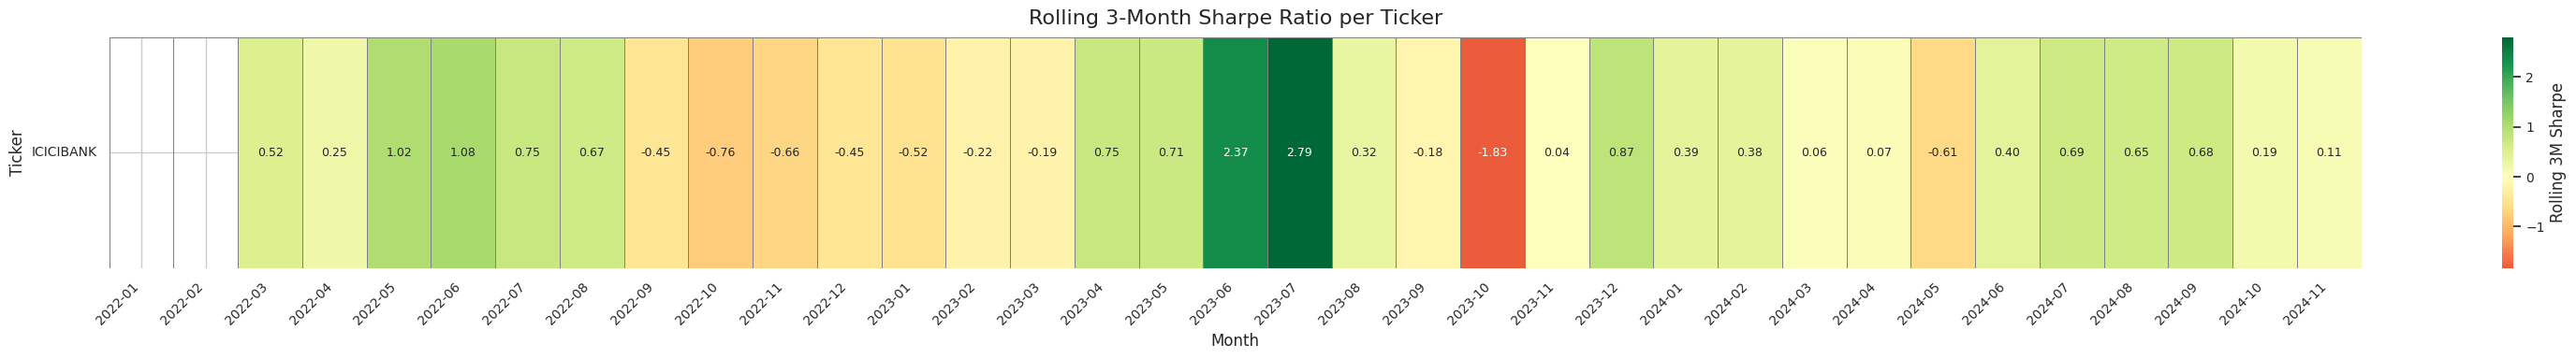

In [22]:
# ── 10. Rolling Sharpe Heatmap per Ticker ────────────────────────────────────
def plot_rolling_sharpe(df: pd.DataFrame, config: dict):
    if "Ticker" not in df.columns:
        print("⚠️   Skipping — 'Ticker' column not found.")
        return
    capital = config["starting_capital"]
    window  = config["rolling_sharpe_window"]

    d = df.copy()
    d["PnL %"] = (d["PnL"] / capital) * 100

    # Build Ticker × Month matrix
    ret_matrix = (
        d.groupby(["Ticker","YearMonth"])["PnL %"]
        .sum()
        .unstack()
        .sort_index(axis=1)
    )

    # NOTE: pandas ≥ 2.0 removed rolling(axis=1); use transpose trick instead.
    rm = ret_matrix.T.rolling(window=window).mean().T
    rs = ret_matrix.T.rolling(window=window).std().T
    rolling_sharpe = (rm / rs).astype(float)

    fig_w = max(24, len(rolling_sharpe.columns) * 0.9)
    fig_h = max(4,  len(rolling_sharpe)         * 0.6)
    plt.figure(figsize=(fig_w, fig_h))
    sns.heatmap(
        rolling_sharpe, annot=True, fmt=".2f",
        cmap="RdYlGn", center=0,
        linewidths=0.4, linecolor="gray",
        cbar_kws={"label": f"Rolling {window}M Sharpe"},
        annot_kws={"size": 9},
    )
    plt.title(f"Rolling {window}-Month Sharpe Ratio per Ticker", fontsize=16, pad=10)
    plt.xlabel("Month"); plt.ylabel("Ticker")
    plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()

plot_rolling_sharpe(df, CONFIG)


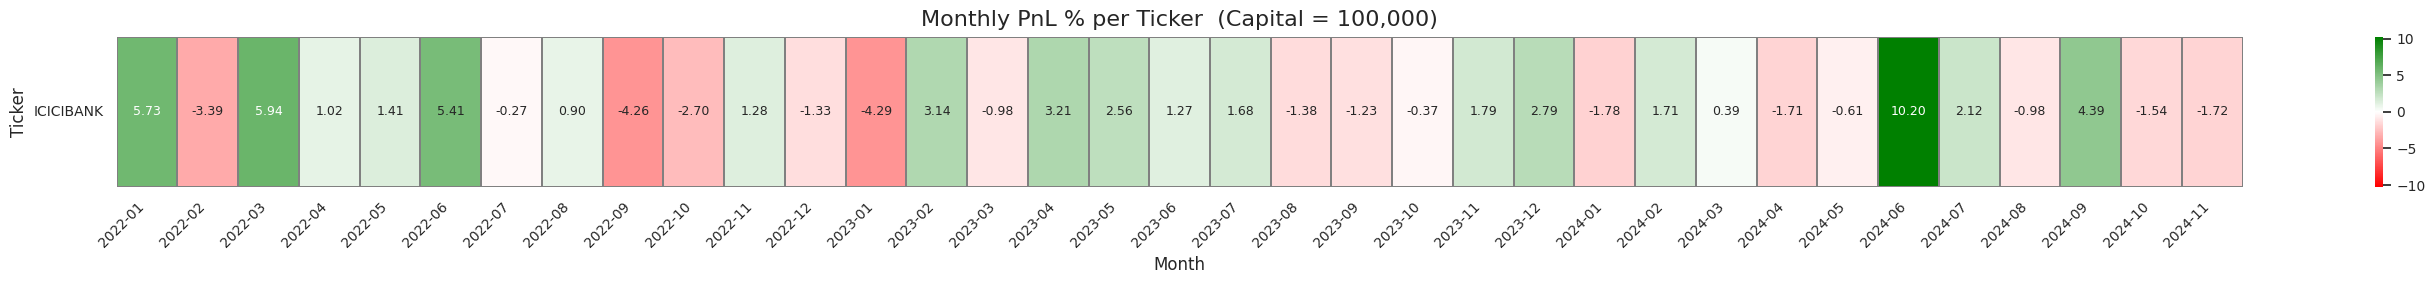

In [23]:
# ── 11. Monthly PnL % per Ticker Heatmap ────────────────────────────────────
def plot_monthly_pnl_per_ticker(df: pd.DataFrame, config: dict):
    if "Ticker" not in df.columns:
        print("⚠️   Skipping — 'Ticker' column not found.")
        return
    capital = config["starting_capital"]

    d = df.copy()
    d["PnL %"] = (d["PnL"] / capital) * 100
    mat = (
        d.groupby(["Ticker","YearMonth"])["PnL %"]
        .sum().unstack().fillna(0)
    )
    mat.columns = mat.columns.astype(str)

    vmax  = abs(mat.values).max() or 1.0
    cmap  = mcolors.LinearSegmentedColormap.from_list("rwg",["red","white","green"])
    fig_w = max(18, len(mat.columns) * 0.8)
    fig_h = max(3,  len(mat)         * 0.55)

    plt.figure(figsize=(fig_w, fig_h))
    sns.heatmap(
        mat, annot=True, fmt=".2f", cmap=cmap,
        center=0, vmin=-vmax, vmax=vmax,
        linewidths=0.1, linecolor="gray",
        annot_kws={"size": 9},
    )
    plt.title(f"Monthly PnL % per Ticker  (Capital = {capital:,})", fontsize=16, pad=8)
    plt.xlabel("Month"); plt.ylabel("Ticker")
    plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()

plot_monthly_pnl_per_ticker(df, CONFIG)


## 🔬 Section 5 — Advanced Analysis

In [24]:
# ── 12. Simultaneous Ticker Overlap ──────────────────────────────────────────
def analyze_ticker_overlap(df: pd.DataFrame):
    if "Ticker" not in df.columns:
        print("⚠️   Skipping — 'Ticker' column not found.")
        return

    mat     = df.pivot_table(index="Entry Time", columns="Ticker", values="PnL")
    traded  = mat.notna() & (mat != 0)
    n_trade = traded.sum(axis=1)
    total   = len(n_trade)
    max_n   = traded.shape[1]

    print(f"\n{'Tickers Traded Simultaneously':<35} {'% of Entries':>12}")
    print("─" * 50)
    for n in range(max_n, 0, -1):
        pct = (n_trade == n).sum() / total * 100
        if pct > 0:
            label = f"  {n} ticker(s) at same entry time"
            print(f"{label:<35} {pct:>11.2f}%")

analyze_ticker_overlap(df)



Tickers Traded Simultaneously       % of Entries
──────────────────────────────────────────────────
  1 ticker(s) at same entry time         100.00%


In [25]:
# ── 13. PnL Correlation Between Tickers ──────────────────────────────────────
def plot_pnl_correlation(df: pd.DataFrame):
    if "Ticker" not in df.columns:
        print("⚠️   Skipping — 'Ticker' column not found.")
        return

    mat  = df.pivot_table(index="Entry Time", columns="Ticker", values="PnL")
    # Keep tickers with ≥10 data points (or ≥10% of rows, whichever is larger)
    min_pts = max(10, len(mat) // 10)
    mat  = mat.dropna(thresh=min_pts, axis=1).fillna(0)
    corr = mat.corr()

    sz = max(500, 80 * len(corr))
    fig = px.imshow(
        corr,
        title="PnL Correlation Between Tickers (aligned by Entry Time)",
        color_continuous_scale="RdBu",
        zmin=-1, zmax=1, text_auto=".2f",
        template="plotly_white",
    )
    fig.update_layout(width=min(1200, sz), height=min(1200, sz))
    fig.show()

plot_pnl_correlation(df)



📊 Performance by Volatility Regime:
                    Avg PnL     Total PnL  Trades  Win Rate %
Regime                                                       
High Volatility -375.628832  -2253.772990       6   50.000000
Low Volatility    91.486424  30647.951875     335   51.940299


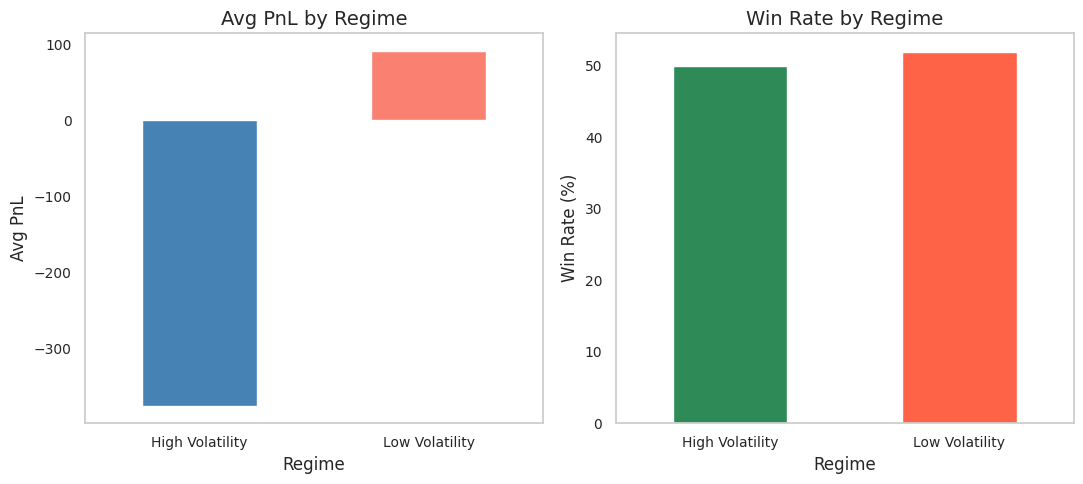

In [26]:
# ── 14. Volatility Regime Analysis  (skipped if price columns absent) ────────
def plot_volatility_regime(df: pd.DataFrame):
    for col in ("Entry Price","Exit Price"):
        if col not in df.columns:
            print(f"⚠️   Skipping — '{col}' column not found.")
            return

    d = df.copy()
    d["_date"] = d["Exit Time"].dt.date

    daily = d.groupby("_date").agg(
        PnL      =("PnL","sum"),
        AvgEntry =("Entry Price","mean"),
        MaxExit  =("Exit Price","max"),
        MinExit  =("Exit Price","min"),
    )
    daily["Range %"] = (daily["MaxExit"] - daily["MinExit"]) / daily["AvgEntry"] * 100
    threshold = daily["Range %"].median()
    daily["Regime"] = np.where(daily["Range %"] > threshold,
                                "High Volatility","Low Volatility")

    d = d.merge(daily[["Regime"]], left_on="_date", right_index=True, how="left")
    d.drop(columns=["_date"], inplace=True)

    stats = (
        d.groupby("Regime")["PnL"]
        .agg(["mean","sum","count"])
        .rename(columns={"mean":"Avg PnL","sum":"Total PnL","count":"Trades"})
    )
    stats["Win Rate %"] = d.groupby("Regime")["Win"].mean() * 100
    print("\n📊 Performance by Volatility Regime:")
    print(stats.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    stats["Avg PnL"].plot(kind="bar", ax=axes[0],
        color=["steelblue","salmon"], title="Avg PnL by Regime")
    axes[0].set_ylabel("Avg PnL"); axes[0].tick_params(axis="x", labelrotation=0)
    axes[0].grid(False)

    stats["Win Rate %"].plot(kind="bar", ax=axes[1],
        color=["seagreen","tomato"], title="Win Rate by Regime")
    axes[1].set_ylabel("Win Rate (%)"); axes[1].tick_params(axis="x", labelrotation=0)
    axes[1].grid(False)

    plt.tight_layout(); plt.show()

plot_volatility_regime(df)


In [27]:
# ── 15. Strategy vs Benchmark  (set CONFIG['benchmark_ticker'] to enable) ────
def plot_benchmark_comparison(df: pd.DataFrame, config: dict):
    bench = config.get("benchmark_ticker")
    if not bench:
        print("ℹ️   Skipping benchmark — set CONFIG['benchmark_ticker'] to a "
              "ticker present in your data.")
        return
    if "Ticker" not in df.columns or bench not in df["Ticker"].values:
        print(f"⚠️   Benchmark ticker '{bench}' not found in 'Ticker' column.")
        return
    if "Exit Price" not in df.columns:
        print("⚠️   'Exit Price' column required for benchmark comparison.")
        return

    capital = config["starting_capital"]
    d = df.copy().sort_values("Exit Time").set_index("Exit Time")

    strat = (d["PnL"].resample("D").sum() / capital * 100).rename("Strategy (%)")

    bench_df = d[d["Ticker"] == bench][["Exit Price"]]
    bench_df = bench_df[~bench_df.index.duplicated(keep="last")]
    bench_r  = (bench_df["Exit Price"].resample("D").last()
                .pct_change() * 100).rename(f"{bench} (%)")

    combined = pd.concat([strat, bench_r], axis=1).dropna()
    if combined.empty:
        print("⚠️   No overlapping daily data for strategy and benchmark."); return

    corr = combined["Strategy (%)"].corr(combined[f"{bench} (%)"])
    fig = px.scatter(
        combined.reset_index(), x=f"{bench} (%)", y="Strategy (%)",
        title=f"Strategy Daily Return vs {bench}  (Pearson r = {corr:.3f})",
        opacity=0.7, template="plotly_white",
    )
    fig.add_hline(y=0, line_dash="dash", line_color="gray")
    fig.add_vline(x=0, line_dash="dash", line_color="gray")
    fig.show()
    print(f"📈  Pearson Correlation with {bench}: {corr:.4f}")

plot_benchmark_comparison(df, CONFIG)


ℹ️   Skipping benchmark — set CONFIG['benchmark_ticker'] to a ticker present in your data.


In [28]:
# ── 16. Cumulative PnL per Ticker (color-coded by ticker) ────────────────────
def plot_cumulative_pnl_per_ticker(df: pd.DataFrame):
    if "Ticker" not in df.columns:
        print("⚠️   Skipping — 'Ticker' column not found.")
        return

    mat = df.pivot_table(index="Entry Time", columns="Ticker", values="PnL")
    min_pts = max(5, len(mat) // 20)
    mat = mat.dropna(thresh=min_pts, axis=1).fillna(0)
    cum = mat.cumsum().subtract(mat.cumsum().iloc[0])  # normalise to 0

    palette = px.colors.qualitative.Plotly
    fig = go.Figure()
    for i, ticker in enumerate(cum.columns):
        fig.add_trace(go.Scatter(
            x=cum.index, y=cum[ticker],
            mode="lines", name=ticker,
            line=dict(color=palette[i % len(palette)], width=1.5),
        ))
    fig.update_layout(
        title="Cumulative PnL per Ticker (all start at 0)",
        xaxis_title="Time", yaxis_title="Cumulative PnL",
        height=550, template="plotly_white", legend_title="Ticker",
    )
    fig.show()

plot_cumulative_pnl_per_ticker(df)


## ⚠️ Section 6 — Risk Management

In [29]:
# ── 17. Margin Call Risk Simulator ───────────────────────────────────────────
def simulate_margin_call(config: dict, extra_dds: list = None):
    capital  = config["starting_capital"]
    leverage = config["leverage"]
    trigger  = config["margin_call_threshold"]
    dds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
    if extra_dds:
        dds = sorted(set(dds) | set(extra_dds))

    print(f"Capital = {capital:,}  |  Leverage = {leverage}×  |  "
          f"Margin-call trigger = {trigger*100:.0f}% of margin")
    print(f"{'Drawdown':>10} | {'Leveraged Loss':>15} | {'Equity':>12} | {'Status':>14}")
    print("─" * 60)
    for dd in dds:
        lev_loss = capital * leverage * dd
        equity   = capital - lev_loss
        margin   = capital / leverage
        mc       = equity < trigger * margin
        status   = "🔴 MARGIN CALL" if mc else "✅ Safe"
        print(f"  {dd*100:>7.1f}%  | {lev_loss:>14,.2f}  | {equity:>11,.2f} | {status}")

simulate_margin_call(CONFIG)


Capital = 100,000  |  Leverage = 1×  |  Margin-call trigger = 25% of margin
  Drawdown |  Leveraged Loss |       Equity |         Status
────────────────────────────────────────────────────────────
      5.0%  |       5,000.00  |   95,000.00 | ✅ Safe
     10.0%  |      10,000.00  |   90,000.00 | ✅ Safe
     15.0%  |      15,000.00  |   85,000.00 | ✅ Safe
     20.0%  |      20,000.00  |   80,000.00 | ✅ Safe
     25.0%  |      25,000.00  |   75,000.00 | ✅ Safe
     30.0%  |      30,000.00  |   70,000.00 | ✅ Safe
     40.0%  |      40,000.00  |   60,000.00 | ✅ Safe
     50.0%  |      50,000.00  |   50,000.00 | ✅ Safe


## 🎲 Section 7 — Monte Carlo Simulation

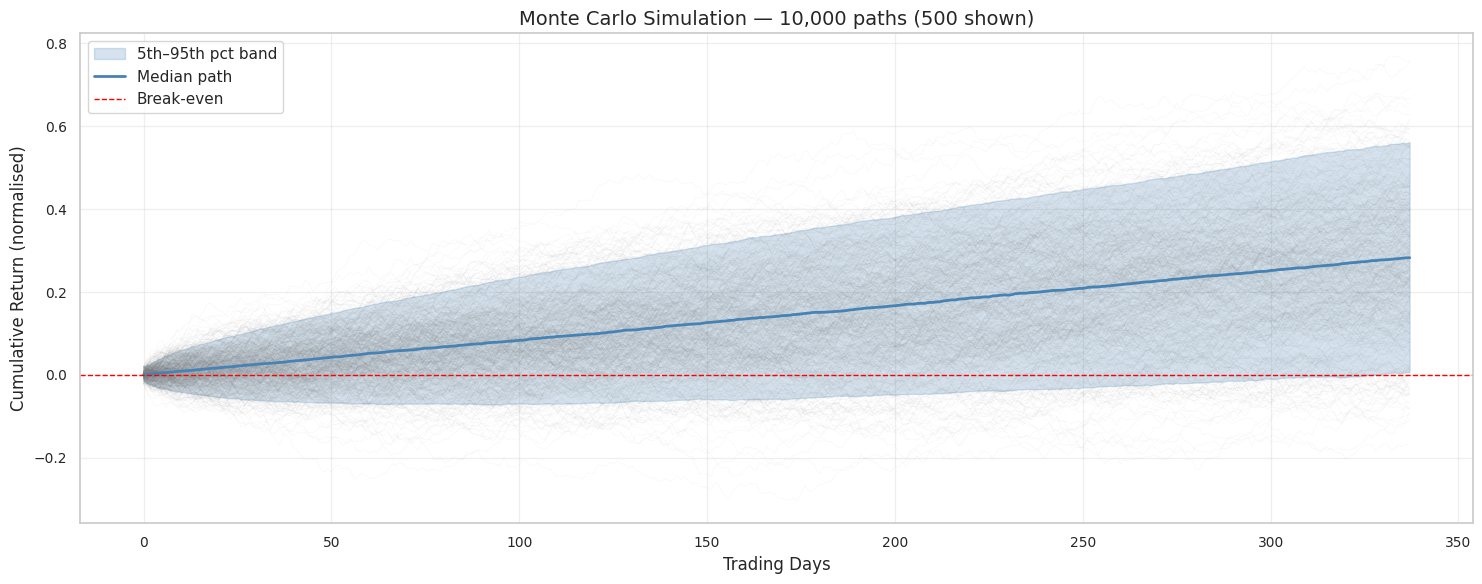

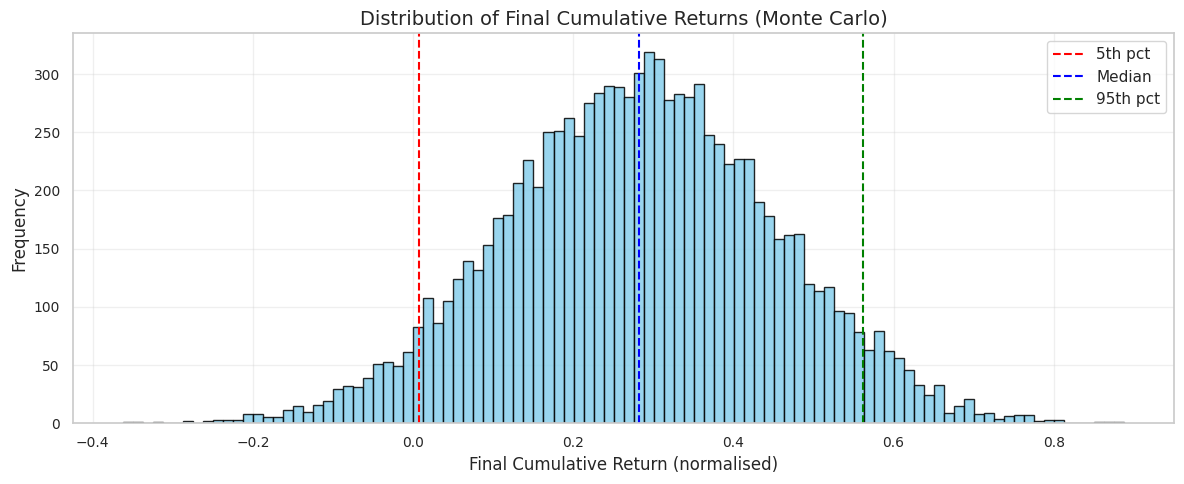


🎲  Monte Carlo — 10,000 sims, 338 days each
    Mean final return    : +0.2823  (+28.23%)
    Median final return  : +0.2827  (+28.27%)
    5th  pct (worst)     : +0.0073  (+0.73%)
    95th pct (best)      : +0.5614  (+56.14%)
    Prob. of profit      : 95.5%
    Min / Max            : -0.3620 / +0.8877


In [30]:
# ── 18. Monte Carlo Simulation ───────────────────────────────────────────────
def run_monte_carlo(df: pd.DataFrame, config: dict):
    capital = config["starting_capital"]
    n_sims  = config["mc_simulations"]
    n_plot  = config["mc_paths_to_plot"]

    daily_pnl = df.groupby("Trade Date")["PnL"].sum()
    daily_ret = (daily_pnl / capital).values     # normalised daily returns
    n_days    = len(daily_ret)

    rng   = np.random.default_rng(seed=42)
    sims  = rng.choice(daily_ret, size=(n_sims, n_days), replace=True)
    cumul = np.cumsum(sims, axis=1)

    # ── Paths plot ────────────────────────────────────────────────────────────
    plt.figure(figsize=(15, 6))
    for path in cumul[:n_plot]:
        plt.plot(path, color="gray", alpha=0.06, linewidth=0.5)

    x   = np.arange(n_days)
    p5  = np.percentile(cumul, 5,  axis=0)
    p50 = np.percentile(cumul, 50, axis=0)
    p95 = np.percentile(cumul, 95, axis=0)
    plt.fill_between(x, p5, p95, alpha=0.22, color="steelblue",
                     label="5th–95th pct band")
    plt.plot(x, p50, color="steelblue", linewidth=2, label="Median path")
    plt.axhline(0, color="red", linewidth=1, linestyle="--", label="Break-even")
    plt.title(f"Monte Carlo Simulation — {n_sims:,} paths ({n_plot} shown)")
    plt.xlabel("Trading Days"); plt.ylabel("Cumulative Return (normalised)")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    # ── Final-return distribution ─────────────────────────────────────────────
    final = cumul[:, -1]
    plt.figure(figsize=(12, 5))
    plt.hist(final, bins=100, color="skyblue", edgecolor="black", alpha=0.85)
    for pct, col, lbl in [(5,"red","5th pct"),(50,"blue","Median"),(95,"green","95th pct")]:
        plt.axvline(np.percentile(final, pct), color=col,
                    linestyle="--", linewidth=1.5, label=lbl)
    plt.title("Distribution of Final Cumulative Returns (Monte Carlo)")
    plt.xlabel("Final Cumulative Return (normalised)")
    plt.ylabel("Frequency")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    pct_profit = (final > 0).mean() * 100
    print(f"\n🎲  Monte Carlo — {n_sims:,} sims, {n_days} days each")
    print(f"    Mean final return    : {np.mean(final):+.4f}  ({np.mean(final)*100:+.2f}%)")
    print(f"    Median final return  : {np.median(final):+.4f}  ({np.median(final)*100:+.2f}%)")
    print(f"    5th  pct (worst)     : {np.percentile(final,5):+.4f}  ({np.percentile(final,5)*100:+.2f}%)")
    print(f"    95th pct (best)      : {np.percentile(final,95):+.4f}  ({np.percentile(final,95)*100:+.2f}%)")
    print(f"    Prob. of profit      : {pct_profit:.1f}%")
    print(f"    Min / Max            : {np.min(final):+.4f} / {np.max(final):+.4f}")

run_monte_carlo(df, CONFIG)


## ⚖️ Section 8 — Weighted Portfolio Analysis

In [31]:
# ── 19. Weighted Portfolio Analysis ──────────────────────────────────────────
def plot_weighted_portfolio(df: pd.DataFrame, config: dict):
    if "Ticker" not in df.columns:
        print("⚠️   Skipping — 'Ticker' column not found.")
        return

    capital = config["starting_capital"]
    weights = config.get("ticker_weights")
    tickers = df["Ticker"].unique()

    if weights is None:
        w = 1.0 / len(tickers)
        weights = {t: w for t in tickers}
        print(f"ℹ️   Equal weights applied: {w:.4f} per ticker ({len(tickers)} tickers)")
    else:
        total_w = sum(weights.values())
        if abs(total_w - 1.0) > 0.01:
            print(f"ℹ️   Normalising weights (sum was {total_w:.4f})")
            weights = {k: v / total_w for k, v in weights.items()}
        missing = [t for t in weights if t not in tickers]
        if missing:
            print(f"⚠️   Tickers in CONFIG['ticker_weights'] not found in data: {missing}")

    d = df.copy()
    d["Weight"]       = d["Ticker"].map(weights).fillna(0)
    d["Weighted PnL"] = d["PnL"] * d["Weight"]
    d["Year"]         = d["Entry Time"].dt.year
    d["Month"]        = d["Entry Time"].dt.month

    monthly = d.groupby(["Year","Month"])["Weighted PnL"].sum().reset_index()
    monthly["Return %"] = (monthly["Weighted PnL"] / capital) * 100
    yearly  = d.groupby("Year")["Weighted PnL"].sum().reset_index()
    yearly["Return %"]  = (yearly["Weighted PnL"]  / capital) * 100

    pivot = monthly.pivot(index="Year", columns="Month", values="Return %")
    pivot = pivot.reindex(columns=range(1, 13), fill_value=np.nan)
    pivot.columns = [calendar.month_abbr[m] for m in pivot.columns]

    text_vals = np.where(np.isnan(pivot.values), "",
                         np.round(pivot.values, 2).astype(str))
    hm = go.Figure(data=go.Heatmap(
        z=pivot.values,
        x=pivot.columns.tolist(),
        y=pivot.index.astype(str).tolist(),
        colorscale="YlGnBu",
        colorbar_title="Return %",
        text=text_vals, texttemplate="%{text}%",
        hovertemplate="Year: %{y}<br>Month: %{x}<br>Return: %{z:.2f}%",
        zmid=0,
    ))
    hm.update_layout(
        title="Monthly Weighted Portfolio Returns (%)",
        xaxis_title="Month", yaxis_title="Year",
        template="plotly_white",
        width=1100, height=max(400, 100 * len(pivot)),
    )
    hm.show()

    colors = ["green" if r >= 0 else "red" for r in yearly["Return %"]]
    bar = go.Figure(go.Bar(
        x=yearly["Year"].astype(str), y=yearly["Return %"],
        marker_color=colors,
        text=(yearly["Return %"].round(2).astype(str) + "%"),
        textposition="outside",
    ))
    bar.update_layout(
        title="Yearly Weighted Portfolio Returns (%)",
        xaxis_title="Year", yaxis_title="Return (%)",
        template="plotly_white", width=900, height=450,
    )
    bar.show()

    print("\n⚖️   Weights applied:")
    for t, w in sorted(weights.items(), key=lambda x: -x[1]):
        mark = "✅" if t in tickers else "❌"
        print(f"   {mark} {t:<18} {w*100:.2f}%")

plot_weighted_portfolio(df, CONFIG)


ℹ️   Equal weights applied: 1.0000 per ticker (1 tickers)



⚖️   Weights applied:
   ✅ ICICIBANK          100.00%
